# Índice

- [Layout completo](#layout-completo)
- [Componentes](#componentes)
  - [MMI 3x3](#mmi-3x3)
  - [Espiral](#espiral)
  - [Wavelength tracker](#wavelength_tracker)
  - [Estructuras de test](#estructuras-de-test)



In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial

PDK.activate()

## LAYOUT COMPLETO

<div align="justify">

El layout completo del chip se divide en tres sectores: top, middle y bottom. En los tres sectores se incluye el diseño del wavelength tracker, junto con las estructuras de test necesarias para caracterizar su funcionamiento.

En los sectores top y bottom, el circuito se ha diseñado con grating couplers para permitir la caracterización vertical. La diferencia entre ambos es que, en el sector bottom, se ha aumentado en 3 µm la longitud de los MMI respecto a la longitud obtenida en la fase de diseño.

Por otro lado, el sector middle se ha diseñado con el objetivo de realizar una caracterización lateral.

Se han definido diversas funciones con el fin de dibujar el diseño deseado. Entre dichas funciones es relevante destacar: mmi3x3, wvl_tracker y las funciones correspondientes a las estructuras de test. Todas las definiciones pueden ser consultadas en el archivo: [`wvl_tracker.py`](/home/maria_romero/pic-upv-lab5-finalproject/src/upvfab/sin300/cband/cells/wvl_tracker.py) 

</div>

2026-05-14 18:38:23.208 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/544555694.oas'


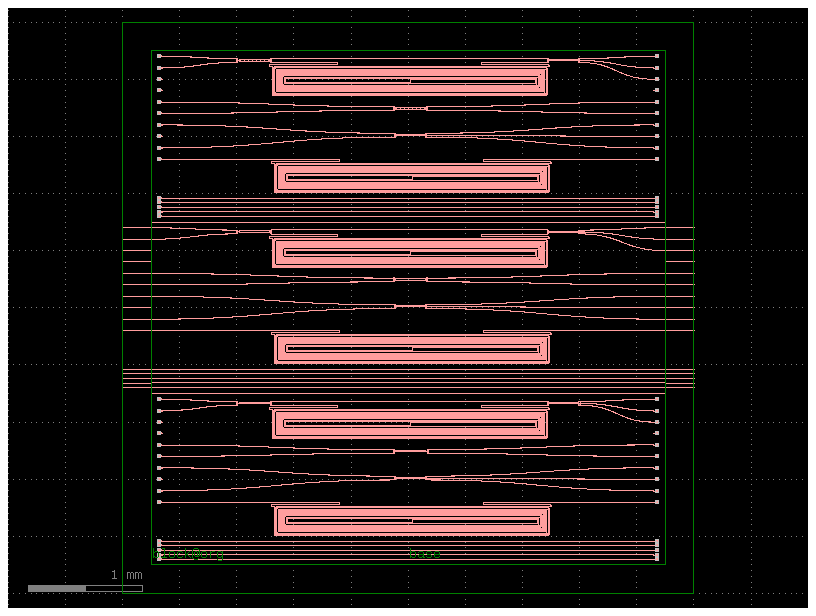

In [2]:
main = gf.Component()
dieW = 5000
border = 250
interior = dieW - 2*border
length_mmi_95_top = 262.9723
length_mmi_33_top = 242.4723

die_ref = main << cells.die(dieW=dieW, border=border, layer_box="FLOORPLAN")
gc = gf.components.grating_coupler_elliptical(layer_slab="SLAB")
waveguide = gf.components.straight(interior - 200)
wvg_lat = gf.components.straight(border)
waveguides_test = [main << gf.components.array(component=(gf.components.straight(interior) if i == 1 else waveguide), columns=1, rows=5, row_pitch=40) for i in range(3)]
gc_top = [main << gf.components.array(component=gc, columns=1, rows=10, row_pitch=100) for _ in range(4)]
gc_down = [main << gf.components.array(component=gc, columns=1, rows=5, row_pitch=40) for _ in range(4)]
spiral_test = [main << cells.spiral_delays_test() for _ in range(3)]
mmi95_test = [main << cells.mmi_2x2_test(length_mmi_2x2=length_mmi_95_top + (3 if i == 2 else 0)) for i in range(3)]
mmi33_test = [main << cells.mmi_3x3_test(length_mmi_3x3=length_mmi_33_top + (3 if i == 2 else 0)) for i in range(3)]
wvl_tracker_ref = [main << cells.wvl_tracker(length_mmi_2x2=length_mmi_95_top + (3 if i == 2 else 0), length_mmi_3x3=length_mmi_33_top + (3 if i == 2 else 0)) for i in range(3)]
lateral_waveguides_top = [main << gf.components.array(component=wvg_lat, columns=1, rows=10, row_pitch=100) for _ in range(2)]
lateral_waveguides_down = [main << gf.components.array(component=wvg_lat, columns=1, rows=5, row_pitch=40) for _ in range(2)]

trench = [main << gf.components.straight(interior) for _ in range(2)]


# referencias para posicionar los ctos

trench[0].dmovex(die_ref["block@org"].dx).dmovey(die_ref["block@org"].dy + 2*interior/3)
trench[1].dmovex(die_ref["block@org"].dx).dmovey(die_ref["block@org"].dy + interior/3)


# posiciones comunes: top, middle, bottom

y_wvl = [die_ref["block@org"].dy + interior - 70, trench[0]["o1"].dy - 70, trench[1]["o1"].dy - 70]
y_spiral = [trench[0]["o1"].dy + 550, trench[1]["o1"].dy + 550,die_ref["base"].dy + 550]
x_waveguides = [die_ref["block@org"].dx + 100, die_ref["block@org"].dx,die_ref["block@org"].dx + 100]
y_waveguides = [trench[0].dy + 50, trench[1].dy + 50, die_ref["base"].dy + 50]

for i in range(3):
    wvl_tracker_ref[i].dmovex(die_ref["block@org"].dx + interior/6).dmovey(y_wvl[i])
    spiral_test[i].dmovex(die_ref["block@org"].dx + interior/4.2).dmovey(y_spiral[i])
    mmi95_test[i].dmovex(die_ref["block@org"].dx + interior/2 - length_mmi_95_top/2).dmovey(wvl_tracker_ref[i]["o1"].dy - 320 - 100)
    mmi33_test[i].dmovex(die_ref["block@org"].dx + interior/2 - length_mmi_33_top/2).dmovey(mmi95_test[i]["o2"].dy - 200)
    waveguides_test[i].dmovex(x_waveguides[i]).dmovey(y_waveguides[i])


# top
gc_top[0].mirror_x()
gc_top[0].dmovex(die_ref["block@org"].dx + 100).dmovey(trench[0]["o1"].dy + 550)
gc_top[1].dmovex(die_ref["block@org"].dx + interior - 100).dmovey(trench[0]["o1"].dy + 550)
gc_down[0].mirror_x()
gc_down[0].dmovex(waveguides_test[0]["o1_1_1"].dx).dmovey(waveguides_test[0]["o1_1_1"].dy)
gc_down[1].dmovex(waveguides_test[0]["o2_1_1"].dx).dmovey(waveguides_test[0]["o1_1_1"].dy)


# middle
lateral_waveguides_top[0].dmovey(trench[1]["o1"].dy + 550)
lateral_waveguides_top[1].dmovex(interior + border).dmovey(trench[1]["o1"].dy + 550)
lateral_waveguides_down[0].dmovey(waveguides_test[1]["o1_1_1"].dy)
lateral_waveguides_down[1].dmovex(interior + border).dmovey(waveguides_test[1]["o1_1_1"].dy)

# bottom
gc_top[2].mirror_x()
gc_top[2].dmovex(die_ref["block@org"].dx + 100).dmovey(die_ref["base"].dy + 550)
gc_top[3].dmovex(die_ref["block@org"].dx + interior - 100).dmovey(die_ref["base"].dy + 550)
gc_down[2].mirror_x()
gc_down[2].dmovex(waveguides_test[2]["o1_1_1"].dx).dmovey(waveguides_test[2]["o1_1_1"].dy)
gc_down[3].dmovex(waveguides_test[2]["o2_1_1"].dx).dmovey(waveguides_test[2]["o1_1_1"].dy)

#top
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_10_1'], port2=wvl_tracker_ref[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o3'], port2=gc_top[1]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_9_1'], port2=wvl_tracker_ref[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o4'], port2=gc_top[1]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o5'], port2=gc_top[1]['o1_8_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_6_1'], port2=mmi95_test[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[0]['o3'], port2=gc_top[1]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_5_1'], port2=mmi95_test[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[0]['o4'], port2=gc_top[1]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_4_1'], port2=mmi33_test[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o3'], port2=gc_top[1]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o4'], port2=gc_top[1]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_2_1'], port2=mmi33_test[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o5'], port2=gc_top[1]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_1_1'], port2=spiral_test[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=spiral_test[0]['o2'], port2=gc_top[1]['o1_1_1'], cross_section="strip")

#middle
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_10_1'], port2=wvl_tracker_ref[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o3'], port2=lateral_waveguides_top[1]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_9_1'], port2=wvl_tracker_ref[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o4'], port2=lateral_waveguides_top[1]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o5'], port2=lateral_waveguides_top[1]['o1_8_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_6_1'], port2=mmi95_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi95_test[1]['o3'], port2=lateral_waveguides_top[1]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_5_1'], port2=mmi95_test[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi95_test[1]['o4'], port2=lateral_waveguides_top[1]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_4_1'], port2=mmi33_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o3'], port2=lateral_waveguides_top[1]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o4'], port2=lateral_waveguides_top[1]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_2_1'], port2=mmi33_test[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o5'], port2=lateral_waveguides_top[1]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_1_1'], port2=spiral_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=spiral_test[1]['o2'], port2=lateral_waveguides_top[1]['o1_1_1'], cross_section="strip")

#bottom
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_10_1'], port2=wvl_tracker_ref[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o3'], port2=gc_top[3]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_9_1'], port2=wvl_tracker_ref[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o4'], port2=gc_top[3]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o5'], port2=gc_top[3]['o1_8_1'], cross_section="strip")


gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_6_1'], port2=mmi95_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[2]['o3'], port2=gc_top[3]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_5_1'], port2=mmi95_test[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[2]['o4'], port2=gc_top[3]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_4_1'], port2=mmi33_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o3'], port2=gc_top[3]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o4'], port2=gc_top[3]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_2_1'], port2=mmi33_test[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o5'], port2=gc_top[3]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_1_1'], port2=spiral_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=spiral_test[2]['o2'], port2=gc_top[3]['o1_1_1'], cross_section="strip")

main.plot()
main.show()

## Componentes

En esta sección se ha preparado una visualización de los dispositivos utilizados para la creación del circuito para poder examinarlos con mayor facilidad. 

### MMI 3x3

2026-05-22 12:19:41.646 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


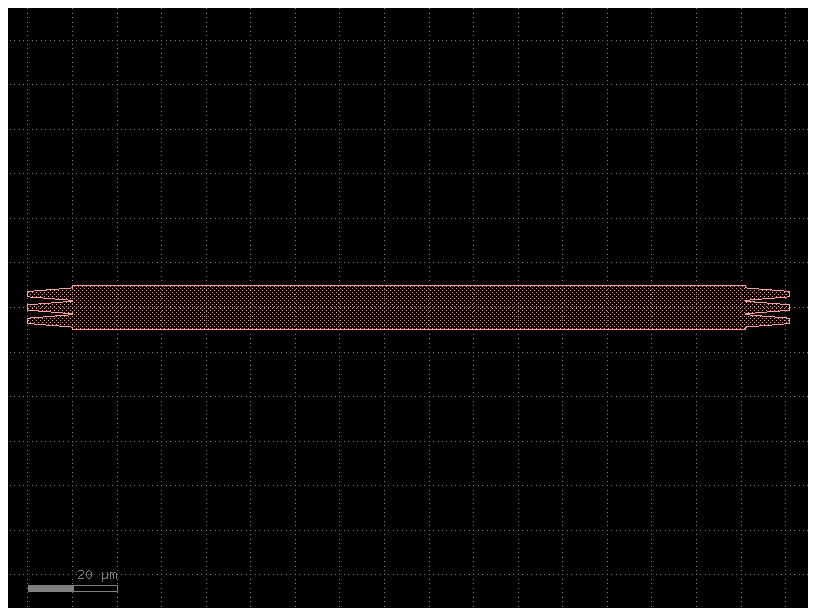

In [5]:
c = cells.mmi3x3(width= 1.2, width_taper=2.8, length_taper= 10.0, length_mmi = 150.9331, width_mmi= 10, gap_mmi = 0.2)

c.show()
c.plot()

### Espiral

In [10]:
rad = 100
N_spr = 12
dy_spr = 12
target_length = 123822  # in microns 
#target_length = 56032.624

dx_length_spiral = cells.define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])

Defining spiral length for delay: 123822
Spiral length set to: 3795.16845703125
Spiral length 123822.005


In [12]:
def wvl_tracker(length_spiral: float = 3795.16845703125, length_mmi_2x2: float = 162.433, taper_width_mmi_2x2: float = 2.8, gap_mmi_2x2: float = 0.5,  taper_length = 10,   length_mmi_3x3: float =  150.9331, taper_width_mmi_3x3: float = 2.8, gap_mmi_3x3: float = 0.2,  AL: float = 56000): #mejorarlo poniendo las funciones de espiral dentro
    c = gf.Component()
   
    mmi_95 = c << cells.mmi2x2(1.2, taper_width_mmi_2x2, taper_length, length_mmi_2x2, 10, gap_mmi_2x2)
    mmi_33 = c << cells.mmi3x3(width= 1.2, width_taper=taper_width_mmi_3x3, length_taper= taper_length, length_mmi = length_mmi_3x3, width_mmi= 10, gap_mmi = gap_mmi_3x3)
    spiral = c << cells.spiral_upv(radius = 100, N_spr = 12 , d_SPR =10 , dx_SPR= length_spiral, dy_SPR = 12, layer = "strip") # N must BE EVEN 
    b1 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    b2 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    
    
    h = spiral.ports["o2"].dx - spiral.ports["o1"].dx
    wvg_up = c << gf.components.straight(length = h, cross_section= "strip", width = 1.2)
    f_bend_euler180 = partial(cells.bend_euler,angle=180)
    delay_1 = c << gf.components.delay_snake(length=h/2, length0=0, length2=0, n=2, bend180=f_bend_euler180(), cross_section='strip', width = 1.2)
    delay_2 = c << gf.components.delay_snake(length=h/2, length0=0, length2=0, n=2, bend180=f_bend_euler180(), cross_section='strip', width = 1.2)

    dy_mmi95 = mmi_95.ports["o3"].dy - mmi_95.ports["o4"].dy #para conectar los s_bend de forma que las entradas a los mmi queden a la misma altura
    dy_mmi33 = mmi_33.ports["o3"].dy - mmi_33.ports["o1"].dy
    h_bends_33 = (2*15 + dy_mmi95 - dy_mmi33)/2
    b3 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    b4 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    

    delay_1.mirror_x().mirror_y()
    delay_1.dmovex(spiral.ports["o1"].dx ).dmovey(spiral.ports["o1"].dy) 
    delay_2.mirror_y()
    delay_2.dmovex(spiral.ports["o2"].dx ).dmovey(spiral.ports["o2"].dy )
    
    b1.mirror_x()
    b1.dmovex(delay_1.ports["o2"].dx).dmovey(delay_1.ports["o2"].dy)
    mmi_95.dmovex(b1.ports["o2"].dx - length_mmi_2x2 - taper_length).dmovey(b1.ports["o2"].dy + taper_width_mmi_2x2/2  + gap_mmi_2x2/2) 
    b2.dmovex(mmi_95.ports["o3"].dx).dmovey(mmi_95.ports["o3"].dy)
    b3.dmovex(delay_2.ports["o2"].dx).dmovey(delay_2.ports["o2"].dy)
    mmi_33.dmovex(b3.ports["o2"].dx + taper_length).dmovey(b3.ports["o2"].dy + taper_width_mmi_3x3 + gap_mmi_3x3 )  
    b4.mirror_x()
    b4.dmovex(mmi_33.ports["o3"].dx).dmovey(mmi_33.ports["o3"].dy)

    wvg_up.dmovex(b2.ports["o2"].dx).dmovey(b2.ports["o2"].dy)

    #bends entrada y salida cto
    b5 = c <<cells.bend_s(size = [10, 15], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    b6 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    b5.mirror_x()
    b5.mirror_y()
    b5.dmovex(mmi_95.ports["o1"].dx).dmovey(mmi_95.ports["o1"].dy)
    b6.mirror_x()
    b6.dmovex(mmi_95.ports["o2"].dx).dmovey(mmi_95.ports["o2"].dy)
    b7 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    b8 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 1.2, allow_min_radius_violation = True)
    wvg = c << gf.components.straight(10, cross_section = "strip")
    b7.mirror_y()
    b8.dmovex(mmi_33.ports["o4"].dx).dmovey(mmi_33.ports["o4"].dy)
    b7.dmovex(mmi_33.ports["o6"].dx).dmovey(mmi_33.ports["o6"].dy)
    wvg.dmovex(mmi_33.ports["o5"].dx).dmovey(mmi_33.ports["o5"].dy)



    c.add_port(name = "o1", port = b6.ports["o2"], port_type= "optical")
    c.add_port(name = "o2", port = b5.ports["o2"], port_type= "optical")
    c.add_port(name = "o3", port = b8.ports["o2"], port_type= "optical")
    c.add_port(name = "o4", port = wvg.ports["o2"], port_type= "optical")
    c.add_port(name = "o5", port = b7.ports["o2"], port_type= "optical")


    c.info["total_length_device"] = 2*taper_length + length_mmi_2x2 + 2*10 + h  + 2*taper_length + length_mmi_3x3 #2*10 es de los sbends
    c.info["length_short_arm"] = h + 2*10
    c.info["h_bends_33"] = h_bends_33

    #normalizar posición para que quede en (0,0)
    
    x0, y0 = c.ports["o1"].dcenter
    c.dmove((-x0, -y0))

    return c 

Longitud total del dispositivo: 4828.5341 um2026-05-22 12:50:59.921 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server

Longitud del brazo corto: 4475.168 um


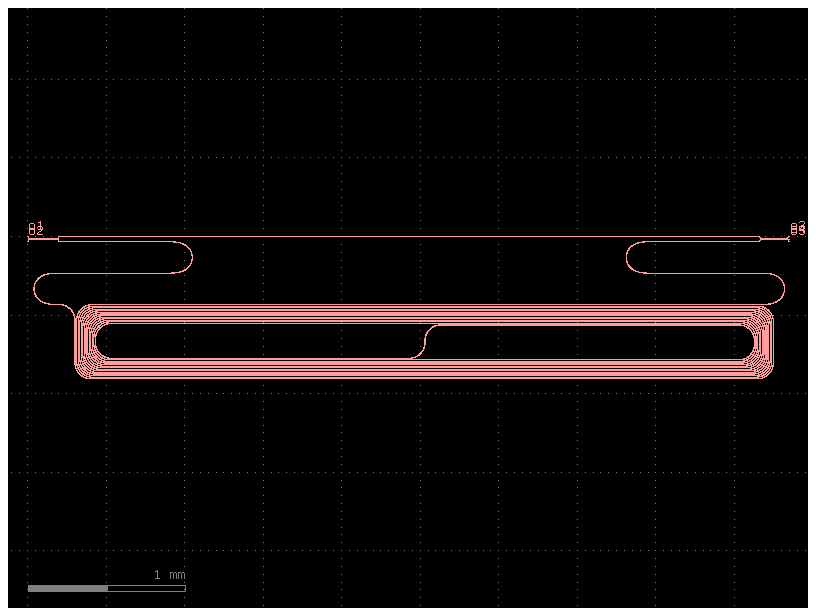

In [14]:
c = gf.Component()
circuito = c <<wvl_tracker()
cto_info = wvl_tracker()
c.add_ports(circuito)
c.draw_ports()
c.plot()
c.show()
print(f'Longitud total del dispositivo: {cto_info.info["total_length_device"]} um')
print(f'Longitud del brazo corto: {cto_info.info["length_short_arm"]} um')
h_bends_33 = cto_info.info["h_bends_33"]

### Wavelength tracker

In [13]:
c = gf.Component()
circuito = c << cells.wvl_tracker()
cto_info = cells.wvl_tracker()
c.add_ports(circuito)
c.draw_ports()
c.plot()
c.show()
print(f'Longitud total del dispositivo: {cto_info.info["total_length_device"]} um')
print(f'Longitud del brazo corto: {cto_info.info["length_short_arm"]} um')
h_bends_33 = cto_info.info["h_bends_33"]

PortWidthMismatchError: Width mismatch between the ports )1["o2"] and Port "o2" ("1200"/"450")

### Estructuras de test

2026-05-15 11:52:17.870 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/2464937446.oas'


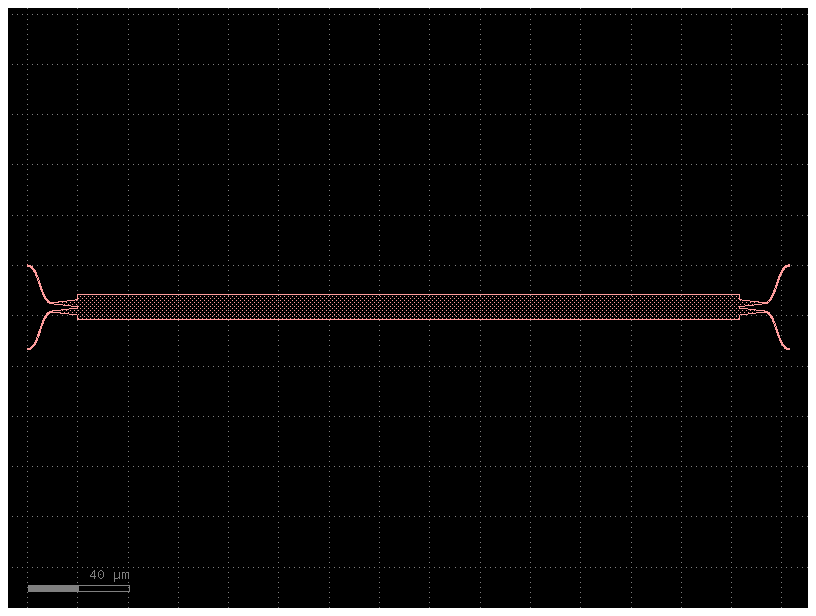

In [2]:

test= cells.mmi_2x2_test()
test.plot()
test.show()



2026-05-15 11:54:30.462 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/3472214404.oas'


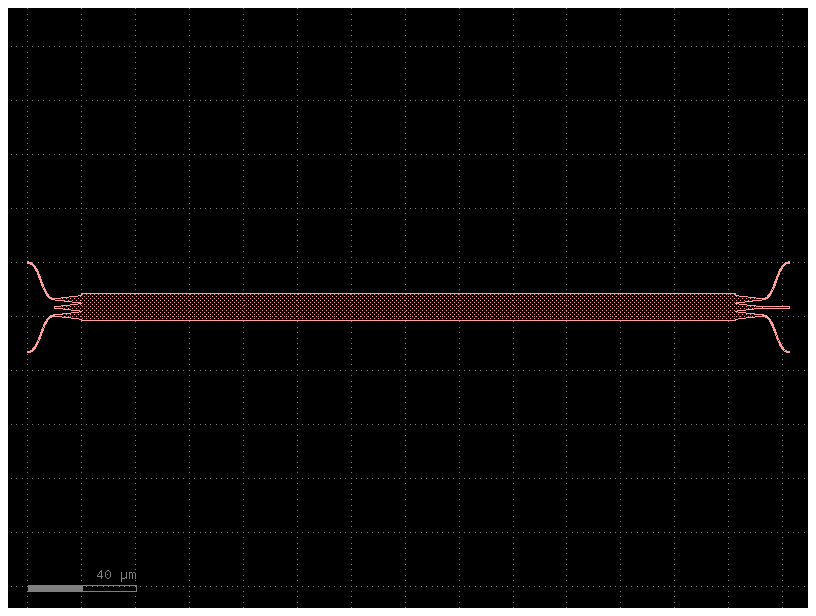

In [3]:

test = cells.mmi_3x3_test()
test.plot()
test.show()
    

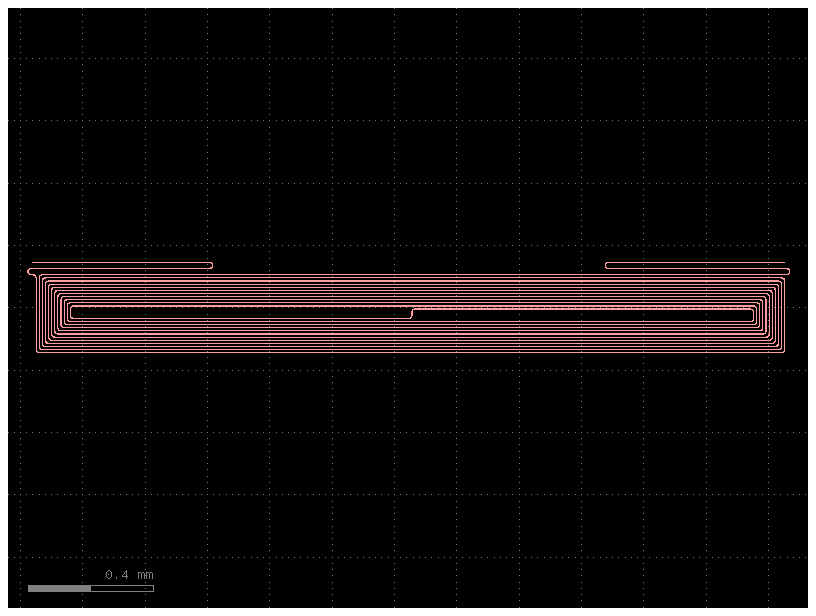

In [ ]:

test = cells.spiral_delays_test()
test.plot()
